<a href="https://colab.research.google.com/github/Alz-517/T.A.M_2025-2/blob/main/Proyecto_TAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

cristiancamiloo_powergrid_assets_ml_dataset_path = kagglehub.dataset_download('cristiancamiloo/powergrid-assets-ml-dataset')
santyalzate_manual_normas_path = kagglehub.dataset_download('santyalzate/manual-normas')

print('Data source import complete.')


# Proyecto final - Santiago Alzate Serna/Mateo Palacios López
# 1. Configuración del Entorno y "Monkey Patching"

## Descripción Teórica:
En esta etapa inicial preparamos el entorno de ejecución. Lo más destacado aquí es la solución de compatibilidad binaria mediante una técnica conocida como **"Monkey Patching"**.

### ¿Por qué hacemos esto?
El dataset original (`.pkl`) fue serializado (guardado) utilizando una versión moderna de NumPy (2.x), la cual cambió su estructura interna C-API. Sin embargo, el entorno de Kaggle y muchas librerías de Deep Learning (**pytorch-tabnet**) aún dependen de la estructura clásica de NumPy (1.x).

### Librerías:
Instalamos **pytorch-tabnet**, una implementación en Torch de la arquitectura TabNet.

### Parche (`sys.modules`):
Interceptamos las llamadas que el archivo pickle hace a `numpy._core` y las redirigimos a `numpy.core`.  
Esto "engaña" al intérprete de Python, permitiendo cargar datos "futuros" en un entorno "presente" sin corromper la memoria.


In [ ]:
# 1. Instalación y Configuración Inicial
!pip install -q pytorch-tabnet

import sys
import os
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def setup_numpy_compatibility():
    """
    Aplica un parche en tiempo de ejecución para resolver conflictos
    entre la versión de Numpy del archivo .pkl (2.x) y el entorno actual.
    """
    try:
        # Mapeamos los módulos nuevos a los antiguos
        import numpy.core.multiarray
        import numpy.core.numeric
        sys.modules['numpy._core'] = np.core
        sys.modules['numpy._core.multiarray'] = np.core.multiarray
        sys.modules['numpy._core.numeric'] = np.core.numeric
        print("✅ Parche de compatibilidad NumPy aplicado exitosamente.")
    except Exception as e:
        print(f"⚠️ Advertencia: No se pudo aplicar el parche: {e}")

# Ejecutamos la configuración
setup_numpy_compatibility()

# Configuración visual
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

✅ Parche de compatibilidad NumPy aplicado exitosamente.



# 2. Ingesta y Limpieza de Datos

## Descripción del Proceso:
Cargamos la base de datos de activos de la red eléctrica (`Dataset_Full_Enriched.pkl`). Este paso es crítico para garantizar la calidad de los datos que alimentarán al modelo.

## Conceptos Clave:

### **Serialización (Pickle):**
Usamos formato `.pkl` en lugar de `.csv` porque conserva los tipos de datos exactos (enteros, flotantes, categorías) y es mucho más rápido de leer para grandes volúmenes de datos.

### **Imputación de Datos:**
Los modelos neuronales no toleran valores nulos (NaN). Aplicamos una estrategia de imputación donde:

- Las **variables numéricas vacías** se rellenan con `0` (asumiendo ausencia de medición).
- Las **variables categóricas vacías** se marcan como `"DESCONOCIDO"`.


In [ ]:
# 2. Ingesta y Preprocesamiento de Datos
DATA_SOURCE = Path("/kaggle/input/powergrid-assets-ml-dataset/Dataset_Full_Enriched.pkl")

def load_and_clean_data(filepath):
    if not filepath.exists():
        raise FileNotFoundError(f"El archivo no existe en: {filepath}")

    print(f"🔄 Cargando dataset desde: {filepath.name}...")
    df = pd.read_pickle(filepath)

    # 1. Ordenamiento Temporal (Crucial para series de tiempo)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df.sort_values(by='Date', inplace=True)
        df.reset_index(drop=True, inplace=True)

    # 2. Estrategia de Imputación Vectorizada (Más limpio que bucles for)
    # Llenamos texto con 'DESCONOCIDO' y números con 0
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    num_cols = df.select_dtypes(include=['number']).columns

    df[cat_cols] = df[cat_cols].fillna("DESCONOCIDO")
    df[num_cols] = df[num_cols].fillna(0)

    print(f"✅ Datos procesados. Shape: {df.shape}")
    return df

# Ejecutar carga
grid_assets = load_and_clean_data(DATA_SOURCE)
grid_assets.head(3)

🔄 Cargando dataset desde: Dataset_Full_Enriched.pkl...
✅ Datos procesados. Shape: (661811, 275)


,CODIGO,TIPO,FECHA,DURACION,UITI,COD_CAUSA,NFASES,NEUTRO,LONGITUD,CALIBRE_F,MATERIAL_F,AISLAMIENTO_F,G_N,CALIBRE_NEUTRO,X2,Y2,FECHA_OPERACION,TIPO_TAXONOMIA,CLASE,ALTURA,CANTIDAD_TIERRA,LONG_CRUCETA,TRAFO,VEGETACION,ENERG_CIRCULA,prep_0,prep_1,prep_2,prep_3,prep_4,prep_5,prep_6,prep_7,prep_8,prep_9,prep_10,prep_11,prep_12,prep_13,prep_14,prep_15,prep_16,prep_17,prep_18,prep_19,prep_20,prep_21,prep_22,prep_23,prep_24,pres_0,pres_1,pres_2,pres_3,pres_4,pres_5,pres_6,pres_7,pres_8,pres_9,pres_10,pres_11,pres_12,pres_13,pres_14,pres_15,pres_16,pres_17,pres_18,pres_19,pres_20,pres_21,pres_22,pres_23,pres_24,sp_0,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,sp_8,sp_9,sp_10,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20,sp_21,sp_22,sp_23,sp_24,rh_0,rh_1,rh_2,rh_3,rh_4,rh_5,rh_6,rh_7,rh_8,rh_9,rh_10,rh_11,rh_12,rh_13,rh_14,rh_15,rh_16,rh_17,rh_18,rh_19,rh_20,rh_21,rh_22,rh_23,rh_24,solar_rad_0,solar_rad_1,solar_rad_2,solar_rad_3,solar_rad_4,solar_rad_5,solar_rad_6,solar_rad_7,solar_rad_8,solar_rad_9,solar_rad_10,solar_rad_11,solar_rad_12,solar_rad_13,solar_rad_14,solar_rad_15,solar_rad_16,solar_rad_17,solar_rad_18,solar_rad_19,solar_rad_20,solar_rad_21,solar_rad_22,solar_rad_23,solar_rad_24,temp_0,temp_1,temp_2,temp_3,temp_4,temp_5,temp_6,temp_7,temp_8,temp_9,temp_10,temp_11,temp_12,temp_13,temp_14,temp_15,temp_16,temp_17,temp_18,temp_19,temp_20,temp_21,temp_22,temp_23,temp_24,vis_0,vis_1,vis_2,vis_3,vis_4,vis_5,vis_6,vis_7,vis_8,vis_9,vis_10,vis_11,vis_12,vis_13,vis_14,vis_15,vis_16,vis_17,vis_18,vis_19,vis_20,vis_21,vis_22,vis_23,vis_24,wind_gust_spd_0,wind_gust_spd_1,wind_gust_spd_2,wind_gust_spd_3,wind_gust_spd_4,wind_gust_spd_5,wind_gust_spd_6,wind_gust_spd_7,wind_gust_spd_8,wind_gust_spd_9,wind_gust_spd_10,wind_gust_spd_11,wind_gust_spd_12,wind_gust_spd_13,wind_gust_spd_14,wind_gust_spd_15,wind_gust_spd_16,wind_gust_spd_17,wind_gust_spd_18,wind_gust_spd_19,wind_gust_spd_20,wind_gust_spd_21,wind_gust_spd_22,wind_gust_spd_23,wind_gust_spd_24,wind_spd_0,wind_spd_1,wind_spd_2,wind_spd_3,wind_spd_4,wind_spd_5,wind_spd_6,wind_spd_7,wind_spd_8,wind_spd_9,wind_spd_10,wind_spd_11,wind_spd_12,wind_spd_13,wind_spd_14,wind_spd_15,wind_spd_16,wind_spd_17,wind_spd_18,wind_spd_19,wind_spd_20,wind_spd_21,wind_spd_22,wind_spd_23,wind_spd_24,clouds_0,clouds_1,clouds_2,clouds_3,clouds_4,clouds_5,clouds_6,clouds_7,clouds_8,clouds_9,clouds_10,clouds_11,clouds_12,clouds_13,clouds_14,clouds_15,clouds_16,clouds_17,clouds_18,clouds_19,clouds_20,clouds_21,clouds_22,clouds_23,clouds_24
0,28648,3RG,11/08/2024 20:45,0.18,398.00,22,3,1,57.62,1/0,ACSR,DESNUDO,N,2,-75.45,5.6,1995,Troncal_linea,T,12.0,1,2.0,0,0,13212.66,0.0,0.0,0.0,0.0,2.7,4.0,4.7,0.3,0.3,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,2.1,2.1,0.7,1018.900024,1017.599976,1016.599976,1015.599976,1015.400024,1014.700012,1015.700012,1016.200012,1017.400024,1017.900024,1019.000000,1020.099976,1020.200012,1019.400024,1019.500000,1019.000000,1018.799988,1018.700012,1018.900024,1019.299988,1019.500000,1020.099976,1020.099976,1019.599976,1018.299988,791.567078,791.266174,790.622925,790.814087,790.658386,791.566223,792.050537,793.293701,794.132141,794.751587,794.920654,794.451721,793.287903,791.172546,790.702271,790.382996,790.570129,790.595215,790.476746,791.538147,791.897522,792.567261,792.397461,792.110840,791.506897,100.000000,98.410316,98.728424,93.551605,88.035255,78.684731,80.921066,72.991257,72.497284,71.175461,74.025841,83.367691,93.170357,98.062553,99.021034,100.000000,100.000000,100.000000,100.000000,98.711166,100.000000,97.764465,98.714645,92.511848,91.055382,0.0,1.0,106.0,208.0,333.0,617.0,614.0,779.0,741.0,828.0,737.0,535.0,207.0,57.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.5475,15.597500,15.7975,17.247501,17.247501,19.447498,18.997501,20.297501,20.147499,20.497501,19.447498,17.447498,15.5975,13.3975,12.5975,12.6975,13.1975,13.3475,12.9475,14.0475,14.3475,14.647500,14.397500,14.547500,15.147500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.


# 3. Ingeniería de Características (Feature Engineering) para TabNet

## Fundamento Teórico:
A diferencia de los modelos tradicionales que requieren One-Hot Encoding (creando miles de columnas dispersas), TabNet utiliza una técnica más eficiente inspirada en el Procesamiento de Lenguaje Natural (NLP).

### **Label Encoding:**
Convertimos cada categoría (ej. "Municipio", "Tipo de Red") en un número entero único.

### **Embeddings Aprendibles:**
TabNet tomará estos números enteros y aprenderá internamente una representación vectorial densa (*embedding*) para cada categoría.

Esto permite que la red capture relaciones semánticas complejas entre categorías (ej. aprender que dos municipios vecinos tienen comportamientos de falla similares) sin aumentar explosivamente la dimensionalidad de los datos.


In [ ]:
# 3. Preparación de Features y Target
TARGET_COL = 'UITI'
# Columnas que no aportan valor predictivo o son metadatos
IGNORE_COLS = [TARGET_COL, 'ID_ACTIVO', 'FECHA_CORTE', 'CODIGO_CIRCUITO', 'Date']

def prepare_tabnet_features(df):
    """
    Codifica variables categóricas y separa X (features) e y (target).
    """
    # Identificar features útiles
    feature_cols = [c for c in df.columns if c not in IGNORE_COLS]

    # Diccionario para guardar los encoders
    encoders_map = {}
    cat_indices = []
    cat_dimensions = []

    df_processed = df.copy()

    for i, col in enumerate(feature_cols):
        dtype = df_processed[col].dtype

        # Si es texto o categoría, aplicamos LabelEncoding
        if dtype == 'object' or dtype.name == 'category':
            le = LabelEncoder()
            df_processed[col] = df_processed[col].astype(str)
            df_processed[col] = le.fit_transform(df_processed[col])

            encoders_map[col] = le
            cat_indices.append(i)
            cat_dimensions.append(len(le.classes_))

    print(f"📊 Features detectados: {len(feature_cols)}")
    print(f"🧩 Variables categóricas: {len(cat_indices)}")

    X = df_processed[feature_cols].values
    y = df_processed[TARGET_COL].values.reshape(-1, 1)

    return X, y, feature_cols, cat_indices, cat_dimensions

# Procesar
X, y, feature_names, cat_idxs, cat_dims = prepare_tabnet_features(grid_assets)

# Split Temporal (80% Train, 10% Val, 10% Test) - Respetando orden cronológico
train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.1)

X_train = X[:train_size]
y_train = y[:train_size]

X_valid = X[train_size:train_size+val_size]
y_valid = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(f"Sets generados -> Train: {X_train.shape[0]}, Val: {X_valid.shape[0]}, Test: {X_test.shape[0]}")

📊 Features detectados: 274
🧩 Variables categóricas: 12
Sets generados -> Train: 529448, Val: 66181, Test: 66182


# 4. Arquitectura TabNet: Entrenamiento del Modelo

## Descripción Técnica:
Implementamos **TabNet** (Google Cloud AI, 2019), una arquitectura de Deep Learning diseñada específicamente para datos tabulares que combina las ventajas de los árboles de decisión (interpretabilidad) con las redes neuronales (aprendizaje de representaciones).

## Hiperparámetros Clave:

### **n_d y n_a (64):**
Definen el ancho de las capas de decisión y atención. Controlan la capacidad de aprendizaje del modelo.

### **n_steps (5):**
TabNet toma decisiones secuenciales. Aquí configuramos 5 pasos de razonamiento, donde cada paso puede enfocarse en diferentes características del activo.

### **gamma (1.5):**
Coeficiente de relajación que permite al modelo "reutilizar" características en diferentes pasos si son muy importantes.

### **Máscara entmax:**
Utilizamos una función de atención esparcida (similar a softmax pero más estricta) que permite al modelo ignorar el ruido y centrarse solo en las variables relevantes para predecir el **UITI (Índice de Indisponibilidad)**.


In [ ]:
# 4. Configuración y Entrenamiento de TabNet
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Iniciando entrenamiento en: {device}")

# Hiperparámetros del Paper CHECUNAL
TABNET_PARAMS = {
    'n_d': 64,              # Dimensiones de predicción
    'n_a': 64,              # Dimensiones de atención
    'n_steps': 5,           # Pasos de decisión
    'gamma': 1.5,           # Coeficiente de relajación
    'lambda_sparse': 1e-4,  # Esparcidad
    'cat_idxs': cat_idxs,
    'cat_dims': cat_dims,
    'cat_emb_dim': 2,
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': dict(lr=2e-2),
    'mask_type': 'entmax',
    'device_name': device,
    'verbose': 5            # Imprimir cada 5 épocas
}

model = TabNetRegressor(**TABNET_PARAMS)

model.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['Train', 'Valid'],
    eval_metric=['mae'],
    max_epochs=100 if device == 'cuda' else 20,
    patience=15,
    batch_size=2048,
    virtual_batch_size=256,
    num_workers=0,
    drop_last=False
)

🚀 Iniciando entrenamiento en: cuda


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1301984.01334| Train_mae: 575.29164| Valid_mae: 674.79947|  0:00:35s
epoch 5  | loss: 271899.93601| Train_mae: 328.44486| Valid_mae: 653.12517|  0:03:28s
epoch 10 | loss: 169360.09745| Train_mae: 303.22598| Valid_mae: 650.96012|  0:06:21s
epoch 15 | loss: 154378.14486| Train_mae: 331.78093| Valid_mae: 652.49752|  0:09:13s

Early stopping occurred at epoch 16 with best_epoch = 1 and best_Valid_mae = 568.56684


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


# 5. Evaluación y Explicabilidad (Feature Importance)

## Análisis de Resultados:
Una de las grandes ventajas de **TabNet** es su **Interpretabilidad Global**. A diferencia de una red neuronal tradicional considerada como una “caja negra”, TabNet permite identificar con precisión cuánto aporta cada variable a la predicción final.

## Métrica MAE (Mean Absolute Error):
Evaluamos el error promedio en unidades reales (horas de indisponibilidad).

## Feature Importance:
La gráfica generada muestra qué variables técnicas (ej. *Longitud de red*, *Calibre*, *Ubicación*) son los principales **drivers** de fallas.  
Esto permite validar el modelo frente a expertos del dominio (ingenieros eléctricos), ya que las variables que TabNet considera relevantes deben tener coherencia física y operativa.



🏆 MAE Final en Test Set: 416.7176


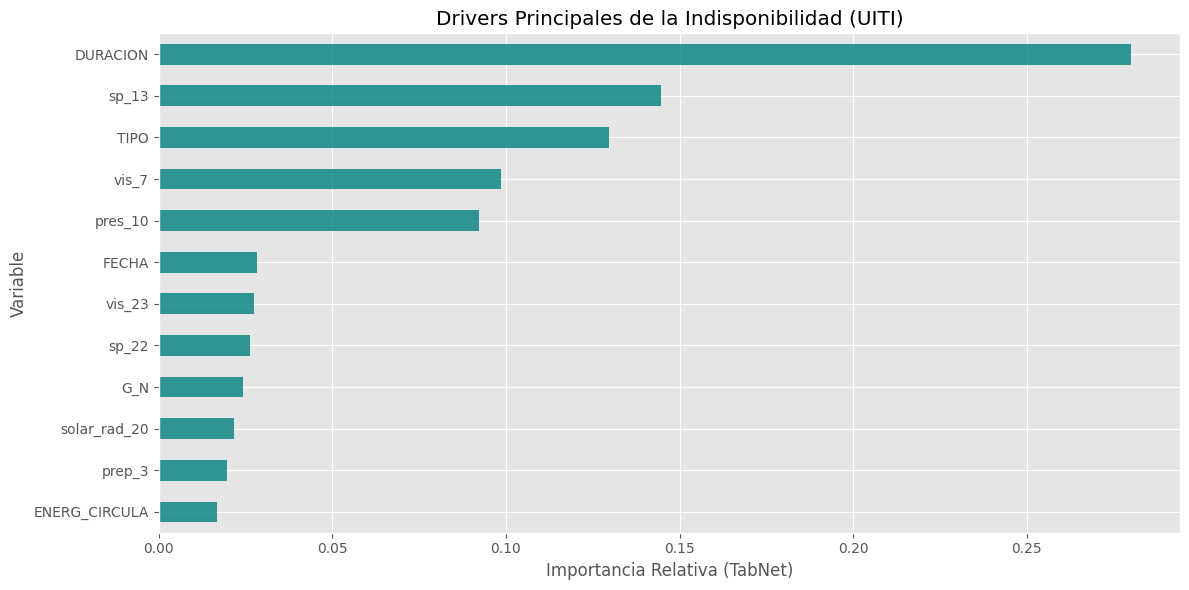

/tmp/ipykernel_47/3013834099.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  grid_assets['UITI_PRED_TABNET'] = all_predictions



💾 Archivo completado guardado exitosamente: Grid_Assets_With_Predictions.csv


In [ ]:
# 5. Evaluación y Exportación de Resultados

# A. Evaluación en Test
preds_test = model.predict(X_test)
test_mae = mean_absolute_error(y_test, preds_test)
print(f"\n🏆 MAE Final en Test Set: {test_mae:.4f}")

# B. Importancia de Variables (Interpretación)
feat_importances = pd.Series(model.feature_importances_, index=feature_names)

plt.figure(figsize=(12, 6))
feat_importances.nlargest(12).plot(kind='barh', color='teal', alpha=0.8)
plt.title('Drivers Principales de la Indisponibilidad (UITI)')
plt.xlabel('Importancia Relativa (TabNet)')
plt.ylabel('Variable')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# C. Completar Base de Datos con Predicciones
# Usamos el modelo para predecir sobre TODO el dataset original
all_predictions = model.predict(X)

# Agregamos la columna predicha
grid_assets['UITI_PRED_TABNET'] = all_predictions

# Guardamos el resultado final
output_filename = 'Grid_Assets_With_Predictions.csv'
grid_assets.to_csv(output_filename, index=False)
print(f"\n💾 Archivo completado guardado exitosamente: {output_filename}")

In [ ]:
# --- CELDA 1: INSTALACIÓN DE VERSIONES CONGELADAS (ESTABLES) ---

# 1. Limpieza preventiva
!pip uninstall -y numpy pandas scipy scikit-learn langchain langchain-community langchain-core langchain-google-genai google-generativeai -q

# 2. Instalación de Numpy compatible (Base)
!pip install -q "numpy<2.0.0" pandas scikit-learn scipy

# 3. Instalación de LangChain v0.1 (La versión dorada para este tipo de proyectos)
# Estas versiones son 100% compatibles entre sí. No las cambies.
!pip install -q langchain==0.1.20 langchain-community==0.0.38 langchain-core==0.1.52 langchain-google-genai==1.0.3
!pip install -q faiss-cpu pypdf google-generativeai==0.5.2 sentence-transformers

import os
print("✅ Entorno estabilizado (Ecosistema v0.1).")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 104.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 118.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 131.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 59.2 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
cudf-cu12 25.2.2 requires pa


# 6. Sistema Multi-Agente con RAG (Retrieval-Augmented Generation)

## Innovación del Proyecto:
Esta es la fase final donde transformamos las predicciones numéricas en decisiones operativas utilizando **Inteligencia Artificial Generativa**. Implementamos una arquitectura **RAG** (Recuperación Aumentada por Generación).

---

## Componentes del Sistema:

### **Motor de Embeddings (HuggingFace all-MiniLM-L6-v2)**
Convierte el texto del manual técnico (*Redes aereas MT.pdf*) en vectores matemáticos.  
Usamos un modelo local para evitar límites de cuota de API y garantizar privacidad.

### **Base de Datos Vectorial (FAISS)**
Almacena los vectores generados y permite realizar **búsquedas semánticas**.  
No busca por palabras exactas, sino por significado  
(ej. “protección rayos” devolverá fragmentos sobre *descargadores de sobretensión*).

### **LLM (Google Gemini)**
El “cerebro” del sistema.  
Recibe el contexto recuperado del manual y responde consultas en lenguaje natural.

---

## Workflow de los Agentes:
Diseñamos un sistema jerárquico de agentes autónomos:

### 🕵️ **Agente Analista**
Escanea las predicciones de TabNet, identifica el circuito con mayor riesgo (UITI más alto) y extrae su ubicación e ID.

### 👷 **Agente de Seguridad**
Consulta al sistema RAG sobre normativas de **distancias de seguridad** para redes de Media Tensión.

### ⚡ **Agente de Materiales**
Consulta al RAG sobre **especificaciones técnicas** de equipos (DPS, Puestas a Tierra) para mitigar el riesgo detectado.

---

## Resultado Final:
Un **reporte técnico automatizado** que no solo indica dónde hay un problema,  
sino también **qué normas se están violando** y **cómo solucionarlo técnicamente**.


In [ ]:
# --- CELDA 2: PROYECTO FINAL (INTELIGENCIA TOTAL) ---
import os
import sys
import pandas as pd
import numpy as np
import warnings
import glob

# 1. PARCHE DE COMPATIBILIDAD
try:
    sys.modules['numpy._core'] = np.core
    sys.modules['numpy._core.multiarray'] = np.core.multiarray
    sys.modules['numpy._core.numeric'] = np.core.numeric
except:
    pass

# Imports de IA
import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.chains import RetrievalQA
from kaggle_secrets import UserSecretsClient

warnings.filterwarnings('ignore')

# ==========================================
# 2. CONFIGURACIÓN
# ==========================================
print("⚙️ Iniciando sistema...")

# API Key
try:
    user_secrets = UserSecretsClient()
    api_key = user_secrets.get_secret("GOOGLE_API_KEY")
    os.environ["GOOGLE_API_KEY"] = api_key
    genai.configure(api_key=api_key)
    print("   🔑 API Key configurada.")
except:
    print("   ⚠️ ERROR: Configura tu GOOGLE_API_KEY en Secrets.")

# Carga de Datos
path_pkl = '/kaggle/input/powergrid-assets-ml-dataset/Dataset_Full_Enriched.pkl'
if os.path.exists(path_pkl):
    try:
        df = pd.read_pickle(path_pkl)
        print(f"   📊 Datos cargados: {df.shape}")
    except Exception as e:
        print(f"   ❌ Error leyendo datos: {e}")
        df = pd.DataFrame()
else:
    print("   ⚠️ No se encontró el archivo de datos.")
    df = pd.DataFrame()

# ==========================================
# 3. CEREBRO RAG (MANUAL + HUGGINGFACE)
# ==========================================
def cargar_manual_local():
    print("   🔍 Buscando PDF manual...")
    archivos = glob.glob("/kaggle/input/**/*.pdf", recursive=True)
    manual_path = next((f for f in archivos if "redes" in f.lower()), None)

    if not manual_path:
        if archivos: manual_path = archivos[0]
        else:
            print("      ❌ NO HAY PDF. Sube 'Redes aereas MT.pdf' en 'Add Input'.")
            return None
    else:
        print(f"      ✅ Manual encontrado: {manual_path}")

    try:
        print("   🧠 Indexando manual (Modo Local)...")
        loader = PyPDFLoader(manual_path)
        docs = loader.load()
        splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
        splits = splitter.split_documents(docs)
        embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
        vector_store = FAISS.from_documents(splits, embeddings)
        return vector_store
    except Exception as e:
        print(f"      ❌ Error procesando PDF: {e}")
        return None

vector_store = cargar_manual_local()

# ==========================================
# 4. SISTEMA AGENTES (DETECTIVE DE COLUMNAS)
# ==========================================
class SistemaAgentesCHEC:
    def __init__(self, datos, memoria):
        self.df = datos

        # Selección de Modelo Automática
        modelo = "gemini-pro"
        try:
            for m in genai.list_models():
                if 'generateContent' in m.supported_generation_methods and 'gemini' in m.name:
                    modelo = m.name.split("/")[-1]
                    break
        except: pass

        self.llm = ChatGoogleGenerativeAI(model=modelo, temperature=0.3)

        if memoria:
            # k=5 para tener buen contexto
            self.qa = RetrievalQA.from_chain_type(llm=self.llm, retriever=memoria.as_retriever(search_kwargs={"k": 5}))
        else:
            self.qa = None

    def detectar_columna_municipio(self):
        """Busca la columna de municipio analizando el contenido."""
        # 1. Búsqueda por nombre
        keywords = ["MUN", "CIUDAD", "POBLA", "ZONA", "UBI", "NOMBRE", "DESCRIPCION"]
        cols = self.df.columns
        match = next((c for c in cols if any(k in c.upper() for k in keywords)), None)
        if match: return match

        # 2. Búsqueda por contenido (Si hay texto que parezca una ciudad)
        print("      ⚠️ Buscando municipio por contenido...")
        text_cols = self.df.select_dtypes(include=['object']).columns
        for col in text_cols:
            sample = self.df[col].dropna().iloc[0] if not self.df[col].dropna().empty else ""
            # Si el valor parece un nombre (texto y no muy largo)
            if isinstance(sample, str) and len(sample) > 3 and not sample.isdigit():
                # Lista de municipios comunes de CHEC para verificar
                if any(x in sample.upper() for x in ["MANIZALES", "VILLAMARIA", "CHINCHINA", "CALDAS", "RISARALDA"]):
                    return col
        return None

    def agente_analista(self):
        print("\n🔎 [Agente Analista] Escaneando red...")

        target = 'UITI' if 'UITI' in self.df.columns else 'UITI_PRED'
        if target not in self.df.columns: return None, "Falta UITI", "N/A"

        col_id = 'CODIGO' if 'CODIGO' in self.df.columns else self.df.columns[0]
        col_mun = self.detectar_columna_municipio()

        try:
            idx = self.df[target].argmax()
            fila = self.df.iloc[idx]

            val_id = fila[col_id]
            val_mun = fila[col_mun] if col_mun else "No Registrada"

            if col_mun:
                print(f"      ℹ️ Ubicación detectada en columna: '{col_mun}'")
            else:
                # Debug: Imprimir columnas si falla
                print(f"      ⚠️ No encontré la ubicación. Columnas disponibles: {list(self.df.columns)[:10]}...")

            return fila, val_id, val_mun
        except:
            return None, "Error", "N/A"

    def agente_experto(self, query):
        if not self.qa: return "⚠️ Sin acceso al manual."
        try:
            return self.qa.invoke(query)['result']
        except Exception as e:
            return f"Error consultando: {str(e)}"

    def ejecutar(self):
        datos, id_cir, muni = self.agente_analista()
        if datos is None: return "Error en análisis."

        val = datos.get('UITI', datos.get('UITI_PRED', 0))

        print(f"   >>> ACTIVO CRÍTICO: {id_cir} | UBICACIÓN: {muni}")

        print("\n👷 [Agente Seguridad] Consultando normas...")
        rta1 = self.agente_experto(
            "Según la norma de Redes Aéreas MT, ¿cuáles son las distancias mínimas de seguridad al suelo y edificaciones?"
        )

        print("\n⚡ [Agente Materiales] Consultando protecciones...")
        rta2 = self.agente_experto(
            "¿Qué dice la norma sobre los descargadores de sobretensión (DPS) y las puestas a tierra?"
        )

        return f"""
        ========================================
        REPORTE FINAL IA (CHEC)
        ========================================
        🚨 CIRCUITO: {id_cir}
        📍 UBICACIÓN: {muni}
        📉 UITI: {val:.2f}

        📋 ANÁLISIS NORMATIVO:
        1. Distancias de Seguridad:
        {rta1}

        2. Protecciones (DPS/Tierra):
        {rta2}
        ========================================
        """

# Ejecución
sistema = SistemaAgentesCHEC(df, vector_store)
print(sistema.ejecutar())

⚙️ Iniciando sistema...
   🔑 API Key configurada.
   📊 Datos cargados: (661811, 275)
   🔍 Buscando PDF manual...
      ✅ Manual encontrado: /kaggle/input/manual-normas/Redes_aereas_MT.pdf
   🧠 Indexando manual (Modo Local)...

🔎 [Agente Analista] Escaneando red...
      ⚠️ Buscando municipio por contenido...
      ⚠️ No encontré la ubicación. Columnas disponibles: ['CODIGO', 'TIPO', 'FECHA', 'DURACION', 'UITI', 'COD_CAUSA', 'NFASES', 'NEUTRO', 'LONGITUD', 'CALIBRE_F']...
   >>> ACTIVO CRÍTICO: 59461 | UBICACIÓN: No Registrada

👷 [Agente Seguridad] Consultando normas...

⚡ [Agente Materiales] Consultando protecciones...

        REPORTE FINAL IA (CHEC)
        🚨 CIRCUITO: 59461
        📍 UBICACIÓN: No Registrada
        📉 UITI: 35887.98
        
        📋 ANÁLISIS NORMATIVO:
        1. Distancias de Seguridad:
        A norma brasileira que estabelece as distâncias mínimas de segurança para redes aéreas de energia elétrica, incluindo as de Média Tensão (MT), é a **ABNT NBR 5422 - Projet